In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt

import utilities as utils

In [2]:
# ---------------------------------------------------------------------------*/
# - parameters of a cavity radio frequency model

q_rf     = 4e7 # loaded quality factor

f_rf     = 1.3e9
w_rf     = 2 * np.pi * f_rf
w_hbw_rf = w_rf/2/q_rf
f_hbw_rf = w_hbw_rf/2/np.pi
t_rf     = round(1/f_hbw_rf, 2)

# generator voltage
v_rf = [10., 0.]

pctr_on_rf = True
K_rf = 10. # proportional controller gain

a_rf = np.array([
    [-w_hbw_rf,  0.      ],
    [ 0.,       -w_hbw_rf]])

b_rf = np.array([
    [w_hbw_rf, 0       ],
    [0,        w_hbw_rf]])

print(f'inf >> half-bandwidth of this radio frequency cavity is {f_hbw_rf:.2f} Herz')
print(f'inf >> cavity filling time is {t_rf:.2f} seconds')

inf >> half-bandwidth of this radio frequency cavity is 16.25 Herz
inf >> cavity filling time is 0.06 seconds


In [3]:
# ---------------------------------------------------------------------------*/
# - parameters of a cavity mechanical model

f_m = 100.
w_m = 2 * np.pi * f_m
q_m = 10.
k_m = 2 * np.pi * 1. # coupling

a_m = np.array([
    [ 0,               1      ],
    [-np.square(w_m), -w_m/q_m]])

b_m = np.array([
    [0],
    [-k_m*np.square(w_m)]])

print(a_m)
print(b_m)

[[ 0.00000000e+00  1.00000000e+00]
 [-3.94784176e+05 -6.28318531e+01]]
[[       0.        ]
 [-2480502.13442399]]


In [4]:
# ---------------------------------------------------------------------------*/
# - solving differential equations

def cav_fn(t, x):
    """
    Executes the logic of cavity differential equations. Input parameters ``t``
    and ``x`` are time and state, respectively.
    """

    # cavity field: real and imaginary
    f_r_rf = x[0]
    f_i_rf = x[1]

    # mechanical mode: displacement and velocity
    disp_m = x[2]
    vcty_m = x[3]

    # current state
    x_rf = np.array([
        [f_r_rf],
        [f_i_rf]])
    x_m  = np.array([
        [disp_m],
        [vcty_m]])

    # input to cavity field: real and imaginary parts of a generator voltage
    u_rf = np.zeros((2, 1))
    if pctr_on_rf:
        # proportional control is on, so calculate an actuation signal u
        r_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

        e_rf = r_rf - x_rf

        u_rf = K_rf * e_rf
    else:
        # proportional control is off, so our setpoint becomes our actuation signal
        u_rf = np.array([
            [v_rf[0]],
            [v_rf[1]]])

    # input to mechanical mode: accelerating field gradient squared
    grad = np.sqrt(np.square(f_r_rf) + np.square(f_i_rf)) # todo: add division by cavity length
    u_m = np.square(grad)

    # update detuning in cavity system dynamics
    a_rf[0,1] = -disp_m
    a_rf[1,0] =  disp_m

    # calculate derivatives
    dx_rf = a_rf @ x_rf + b_rf @ u_rf
    dx_m  = a_m  @ x_m  + b_m  * u_m

    return np.array([dx_rf[0,0], dx_rf[1,0], dx_m[0,0], dx_m[1,0]])

t_span = [0, 2*t_rf]
dt = 0.0001
t = np.arange(t_span[0], t_span[1], dt)

x0 = [
    0,  # cavity field real
    0,  # cavity field imaginary
    0,  # mechanical mode displacement
    0 ] # mechnical mode velocity

y = solve_ivp(cav_fn, t_span, x0, method='RK45', t_eval=t)

inf >> time step for simulation is 0.0001
inf >> number of time steps is 1200


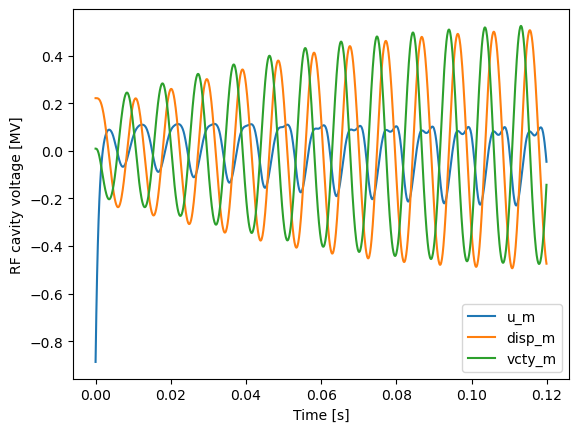

In [5]:
# ---------------------------------------------------------------------------*/
# - conditioning simulated data

print(f'inf >> time step for simulation is {dt:.4f}')
print(f'inf >> number of time steps is {len(t)}')

def cond_simdata(data):
    data = (data - np.min(data)) / (np.max(data) - np.min(data))
    data = data - np.mean(data)
    return data

fld_r_rf = y.y[0, :]
fld_i_rf = y.y[1, :]

disp_m         = cond_simdata(y.y[2, :])
vcty_m         = cond_simdata(y.y[3, :])
grad_m         = cond_simdata(np.sqrt(np.square(fld_r_rf) + np.square(fld_i_rf)))

plt.figure()
#plt.plot(y.t, fld_r_rf, label='field_r_rf')
#plt.plot(y.t, fld_i_rf, label='field_i_rf')
plt.plot(y.t, grad_m, label='u_m')
plt.plot(y.t, disp_m, label='disp_m')
plt.plot(y.t, vcty_m, label='vcty_m')
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('RF cavity voltage [MV]')
#plt.xlim([0, 0.01])
#plt.ylim([-1, 1])
#plt.savefig(f'fig/cavity/datagen_pctr_on_kp_100_vr_10_wm_10.svg')
plt.show()

In [6]:
# ---------------------------------------------------------------------------*/
# - saving simulation data to files

def get_timeseries(t_range, ts_len, *data):
    t_start  = t_range[0]
    t_end    = t_range[1]
    ts_start = int((t_end - t_start)*np.random.rand() + t_start)
    ts_end   = ts_start + ts_len

    return np.concatenate([
        datum[ts_start:ts_end, np.newaxis] for datum in data], axis=1)

dataset_dir = 'cavity'

timeseries_config = [
    # batch size, file name
    (3500, 'train1'),
    (3500, 'train2'),
    (3500, 'train3'),
    (3500, 'train4'),
    (3500, 'train5'),
    (3500, 'train6'),
    (1000, 'valid'),
    (500,  'test')]

timeseries_len = 101
t_start = 0.01 # skip transient process
t_end   = len(t) - timeseries_len
t_range = (t_start, t_end)

for this, cfg in enumerate(timeseries_config):
    np.random.seed(this + 1)
    data = np.stack([
        get_timeseries(
            t_range, timeseries_len,
            disp_m,
            vcty_m,
            grad_m) for _ in range(cfg[0])], axis=0)

    utils.write_datafile(f'{dataset_dir}/{cfg[1]}', data)
